# Class Separability Analysis - Wi-Fi CSI Pipeline v0

**Source**: `pilot/outputs/pipeline_v0/features_v0_ht40` (read-only)
**Features**: 648 columns - 162 shared valid subcarriers × {var, MAD, range, IQR}
**Windows**: 1 200 non-overlapping 2-second windows (300 per session: C, D, E, F)

## Dataset labels

| Class (binary) | 3-class label | Session(s) | Windows |
|----------------|--------------|------------|---------|
| 0 - empty | empty | C, F | 600 |
| 1 - occupied | occupied_still | D | 300 |
| 1 - occupied | occupied_moving | E | 300 |

## Notebook structure
- **Section A** - PCA: global feature-space view (binary and 3-class)
- **Section B** - LDA: optimal linear projection for class separation
- **Section C** - Aggregated feature distributions and statistical tests
- **Section D** - Per-subcarrier discriminability (ANOVA F-statistic profile)
- **Section E** - Pairplot and summary


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy import stats
import json
import warnings
warnings.filterwarnings('ignore')

# Publication-quality aesthetics
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'figure.facecolor':  'white',
    'axes.facecolor':    '#fafafa',
    'axes.edgecolor':    '#444444',
    'axes.linewidth':    0.8,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'legend.framealpha': 0.92,
    'legend.fontsize':   10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    11,
})

# Okabe-Ito palette (color-blind safe)
COLOR_EMPTY   = '#0072B2'
COLOR_STILL   = '#9E0000'
COLOR_MOVING  = '#E69F00'
COLOR_OCC     = '#D55E00'   # occupied (binary)

PAL_BIN = {'empty': COLOR_EMPTY, 'occupied': COLOR_OCC}
PAL_3CL = {'empty': COLOR_EMPTY, 'occupied_still': COLOR_STILL,
            'occupied_moving': COLOR_MOVING}

ORDER_3CL = ['empty', 'occupied_still', 'occupied_moving']

print("Imports OK | sklearn", __import__('sklearn').__version__,
      "| matplotlib", matplotlib.__version__)


Imports OK | sklearn 1.8.0 | matplotlib 3.10.8


In [2]:
# Locate repository root and load pipeline v0 outputs (read-only)

# Locate repo root regardless of where Jupyter was launched from
_p = Path.cwd()
for PROJECT_ROOT in [_p, _p.parent, _p.parent.parent]:
    if (PROJECT_ROOT / 'requirements.txt').exists():
        break

PIPELINE_DIR = PROJECT_ROOT / 'outputs' / 'pilot' / 'pipeline_v0'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'pilot' / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load feature dataset (Parquet preferred for speed)
try:
    df = pd.read_parquet(PIPELINE_DIR / 'features_v0_ht40.parquet')
    print(f"Loaded from Parquet: {df.shape}")
except Exception:
    df = pd.read_csv(PIPELINE_DIR / 'features_v0_ht40.csv')
    print(f"Loaded from CSV: {df.shape}")

# Load subcarrier mapping and pipeline report
sc_map = pd.read_csv(PIPELINE_DIR / 'valid_subcarrier_mapping_v0.csv')
with open(PIPELINE_DIR / 'pipeline_report_v0.json') as f:
    report = json.load(f)

print(f"Valid subcarriers : {len(sc_map)} (raw indices {sc_map['raw_subcarrier_index'].min()}–{sc_map['raw_subcarrier_index'].max()})")
print(f"Pipeline version  : {report.get('notebook_version','-')}")
print(f"Window size       : {report['configuration']['WINDOW_SECONDS']} s")


Loaded from Parquet: (1200, 657)
Valid subcarriers : 162 (raw indices 6–190)
Pipeline version  : v0.1.0
Window size       : 2.0 s


In [3]:
# Labels, feature groups, and aggregated statistics

# Binary label (already in 'label' / 'label_name')
# 3-class label: label_name already has 'empty' / 'occupied_still' / 'occupied_moving'
df['label3'] = df['label_name']   # alias for clarity

# Binary label string for plotting
df['label_bin'] = df['label'].map({0: 'empty', 1: 'occupied'})

# Feature column groups
FT = ['var', 'mad', 'range', 'iqr']
FT_LABELS = {'var': 'Variance', 'mad': 'MAD', 'range': 'Range', 'iqr': 'IQR'}
feat_cols  = {ft: [c for c in df.columns if c.endswith(f'_{ft}')] for ft in FT}
all_feat   = [c for ft in FT for c in feat_cols[ft]]

# Aggregated features: mean across 162 subcarriers
for ft in FT:
    df[f'agg_{ft}'] = df[feat_cols[ft]].mean(axis=1)

print(f"Feature groups: { {ft: len(cols) for ft, cols in feat_cols.items()} }")
print(f"Total features: {len(all_feat)}")

# Class distribution
dist = df.groupby(['label_bin', 'label3', 'session_id']).size().rename('windows')
print("\nClass distribution:")
print(dist.to_string())


Feature groups: {'var': 162, 'mad': 162, 'range': 162, 'iqr': 162}
Total features: 648

Class distribution:
label_bin  label3           session_id
empty      empty            C             300
                            F             300
occupied   occupied_moving  E             300
           occupied_still   D             300


In [4]:
# Standardization, PCA, and LDA (computed once, reused across figures)

# Standardize
X_raw    = df[all_feat].values          # (1200, 648)
scaler   = StandardScaler()
X        = scaler.fit_transform(X_raw)  # zero-mean, unit-variance

# PCA (keep 50 components for scree)
pca      = PCA(n_components=50, random_state=42)
X_pca    = pca.fit_transform(X)         # (1200, 50)
ev       = pca.explained_variance_ratio_

# LDA - binary
y_bin    = df['label'].values
lda_bin  = LDA()
X_lda1   = lda_bin.fit_transform(X, y_bin).ravel()   # (1200,)

# LDA - 3-class
y_3cl    = df['label3'].map({'empty': 0, 'occupied_still': 1, 'occupied_moving': 2}).values
lda_3cl  = LDA()
X_lda2   = lda_3cl.fit_transform(X, y_3cl)            # (1200, 2)

print(f"PCA: 2 PCs explain {ev[:2].sum()*100:.1f}%  |  10 PCs: {ev[:10].sum()*100:.1f}%  |  50 PCs: {ev[:50].sum()*100:.1f}%")
print(f"LDA binary score range : [{X_lda1.min():.2f}, {X_lda1.max():.2f}]")
print(f"LDA 3-class shape      : {X_lda2.shape}")

# ── Helper: 2σ confidence ellipse from covariance ──────────────────────────
def plot_ellipse(ax, x, y, n_std=2.0, **kw):
    """Draw a 2σ confidence ellipse for 2D scatter data."""
    cov = np.cov(x, y)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = np.maximum(eigvals[order], 0)
    eigvecs = eigvecs[:, order]
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    w, h  = 2 * n_std * np.sqrt(eigvals)
    ell   = mpatches.Ellipse(xy=(x.mean(), y.mean()), width=w, height=h, angle=angle, **kw)
    ax.add_patch(ell)
    return ell


PCA: 2 PCs explain 86.3%  |  10 PCs: 95.8%  |  50 PCs: 98.3%
LDA binary score range : [-9.67, 9.10]
LDA 3-class shape      : (1200, 2)


---
## Section A - PCA: Global Feature-Space View

PCA projects 648 features onto uncorrelated principal components. The first two
components capture the directions of maximum variance. Class clustering in the
PCA space indicates that the feature set encodes class-relevant information.

The shaded ellipses mark the 2σ (95.4 %) confidence region for each class.


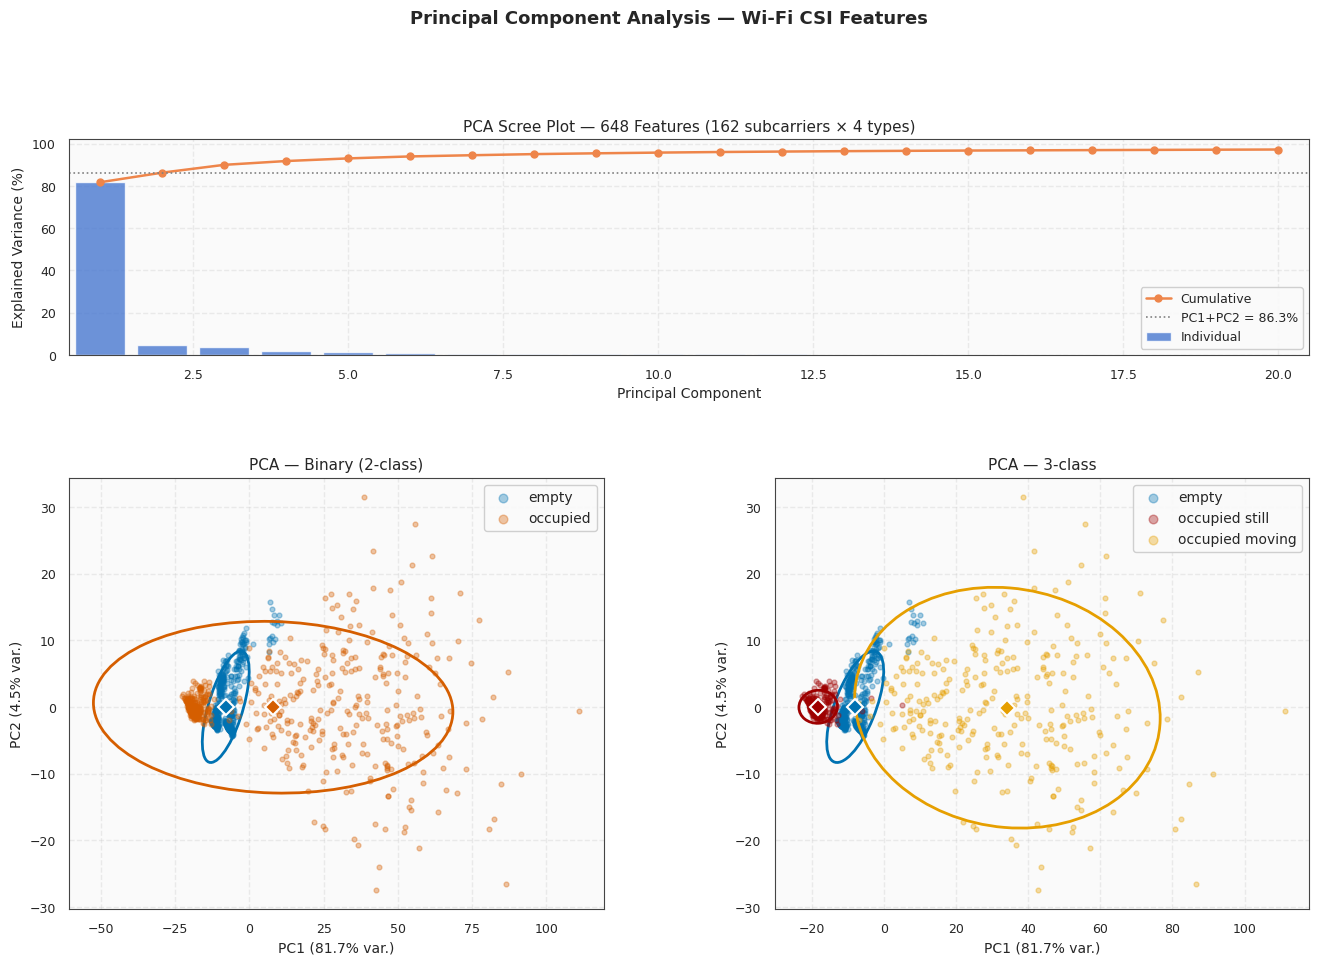

Figure saved: sep_01_pca.png


In [5]:
# Figure 1 - PCA: scree plot + binary scatter + 3-class scatter
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.32,
                        height_ratios=[1, 2])

ax_scree  = fig.add_subplot(gs[0, :])   # full-width scree
ax_pca_b  = fig.add_subplot(gs[1, 0])  # binary PCA
ax_pca_3  = fig.add_subplot(gs[1, 1])  # 3-class PCA

# ── Scree plot ──
n_show = 20
ax_scree.bar(range(1, n_show + 1), ev[:n_show] * 100,
             color='#4878D0', alpha=0.8, label='Individual')
ax_scree.plot(range(1, n_show + 1), ev[:n_show].cumsum() * 100,
              'o-', color='#EE854A', lw=1.8, ms=5, label='Cumulative')
ax_scree.axhline(ev[:2].sum() * 100, color='gray', ls=':', lw=1.2,
                  label=f'PC1+PC2 = {ev[:2].sum()*100:.1f}%')
ax_scree.set_xlabel('Principal Component')
ax_scree.set_ylabel('Explained Variance (%)')
ax_scree.set_title('PCA Scree Plot - 648 Features (162 subcarriers × 4 types)')
ax_scree.legend(fontsize=9)
ax_scree.set_xlim(0.5, n_show + 0.5)

# ── Binary PCA scatter ──
pc1_lbl = f'PC1 ({ev[0]*100:.1f}% var.)'
pc2_lbl = f'PC2 ({ev[1]*100:.1f}% var.)'

for lbl, color in PAL_BIN.items():
    m = df['label_bin'] == lbl
    ax_pca_b.scatter(X_pca[m, 0], X_pca[m, 1], c=color, alpha=0.35,
                     s=12, label=lbl, rasterized=True)
    plot_ellipse(ax_pca_b, X_pca[m, 0], X_pca[m, 1],
                 facecolor='none', edgecolor=color, lw=2.0, n_std=2)
    ax_pca_b.plot(X_pca[m, 0].mean(), X_pca[m, 1].mean(),
                  marker='D', color=color, ms=8, markeredgecolor='white',
                  markeredgewidth=1.5, zorder=5)

ax_pca_b.set_xlabel(pc1_lbl); ax_pca_b.set_ylabel(pc2_lbl)
ax_pca_b.set_title('PCA - Binary (2-class)')
ax_pca_b.legend(markerscale=1.8)

# ── 3-class PCA scatter ──
for lbl in ORDER_3CL:
    color = PAL_3CL[lbl]
    m = df['label3'] == lbl
    ax_pca_3.scatter(X_pca[m, 0], X_pca[m, 1], c=color, alpha=0.35,
                     s=12, label=lbl.replace('_', ' '), rasterized=True)
    plot_ellipse(ax_pca_3, X_pca[m, 0], X_pca[m, 1],
                 facecolor='none', edgecolor=color, lw=2.0, n_std=2)
    ax_pca_3.plot(X_pca[m, 0].mean(), X_pca[m, 1].mean(),
                  marker='D', color=color, ms=8, markeredgecolor='white',
                  markeredgewidth=1.5, zorder=5)

ax_pca_3.set_xlabel(pc1_lbl); ax_pca_3.set_ylabel(pc2_lbl)
ax_pca_3.set_title('PCA - 3-class')
ax_pca_3.legend(markerscale=1.8)

fig.suptitle('Principal Component Analysis - Wi-Fi CSI Features',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(OUTPUT_DIR / 'sep_01_pca.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"Figure saved: sep_01_pca.png")


---
## Section B - LDA: Optimal Linear Projection

Linear Discriminant Analysis finds the linear combination of features that
maximises between-class variance relative to within-class variance.

- **Binary** (1 discriminant): histogram/KDE in the 1D LDA space
- **3-class** (2 discriminants): 2D scatter in the LD1–LD2 plane

Larger separation between class distributions in LDA space indicates better
linear separability of the feature set.


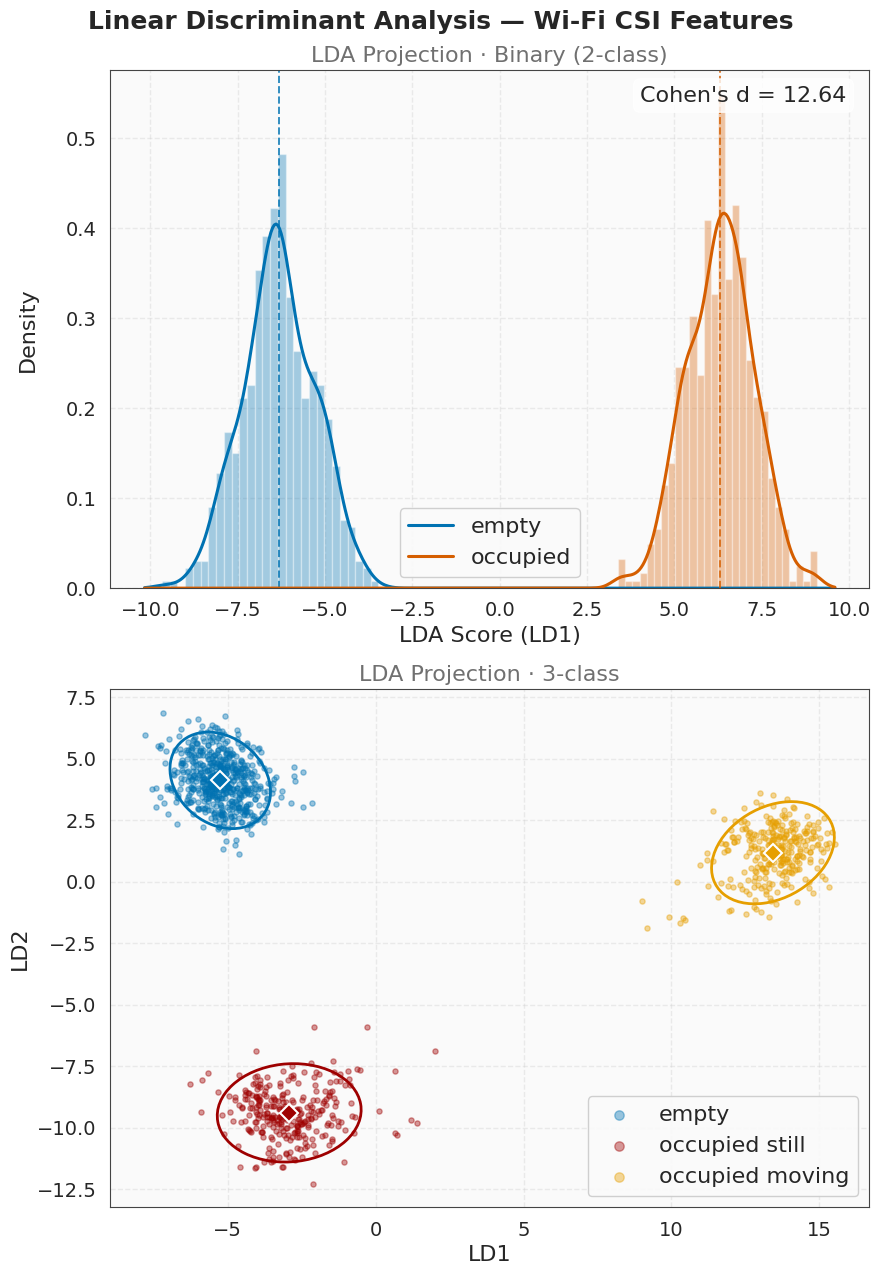

Figure saved: sep_02_lda.png  |  Binary LDA Cohen's d = 12.643


In [6]:
# Figure 2 - LDA projections: binary (1D) and 3-class (2D)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 13))

ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='both', labelsize=14)

# ── Left: binary LDA - KDE histogram ──
t_range = np.linspace(X_lda1.min() - 0.5, X_lda1.max() + 0.5, 400)
for lbl, color in PAL_BIN.items():
    m = df['label_bin'] == lbl
    vals = X_lda1[m]
    ax1.hist(vals, bins=28, color=color, alpha=0.35, density=True)
    kde = stats.gaussian_kde(vals, bw_method='scott')
    ax1.plot(t_range, kde(t_range), color=color, lw=2.2, label=lbl)
    ax1.axvline(vals.mean(), color=color, lw=1.4, ls='--', alpha=0.8)

ax1.set_xlabel('LDA Score (LD1)', fontsize= 16)
ax1.set_ylabel('Density', fontsize=16, labelpad=20)
ax1.set_title('LDA Projection · Binary (2-class)', fontsize=16, color="#707070") # colocar cor cinza
ax1.legend(fontsize=16)

# Mahalanobis-like separation: |μ1 - μ2| / σ_pooled
m0 = df['label_bin'] == 'empty';     m1 = df['label_bin'] == 'occupied'
mu0, mu1 = X_lda1[m0].mean(), X_lda1[m1].mean()
sp = np.sqrt(((len(X_lda1[m0])-1)*X_lda1[m0].var() + (len(X_lda1[m1])-1)*X_lda1[m1].var())
             / (len(X_lda1)-2))
cohens_d = abs(mu1 - mu0) / sp
ax1.text(0.97, 0.97, f"Cohen's d = {cohens_d:.2f}", transform=ax1.transAxes,
         ha='right', va='top', fontsize=16,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

# ── Right: 3-class LDA - 2D scatter ──
for lbl in ORDER_3CL:
    color = PAL_3CL[lbl]
    m = df['label3'] == lbl
    ax2.scatter(X_lda2[m, 0], X_lda2[m, 1], c=color, alpha=0.40,
                s=14, label=lbl.replace('_', ' '), rasterized=True)
    plot_ellipse(ax2, X_lda2[m, 0], X_lda2[m, 1],
                 facecolor='none', edgecolor=color, lw=2.0, n_std=2)
    ax2.plot(X_lda2[m, 0].mean(), X_lda2[m, 1].mean(),
             marker='D', color=color, ms=9, markeredgecolor='white',
             markeredgewidth=1.5, zorder=5)

ax2.set_xlabel('LD1', fontsize=16)
ax2.set_ylabel('LD2', fontsize=16, labelpad=5)
ax2.set_title('LDA Projection · 3-class', fontsize=16, color="#707070")
ax2.legend(markerscale=1.8, fontsize=16)

fig.suptitle('Linear Discriminant Analysis - Wi-Fi CSI Features',
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sep_02_lda.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"Figure saved: sep_02_lda.png  |  Binary LDA Cohen's d = {cohens_d:.3f}")


---
## Section C - Aggregated Feature Distributions

For each of the 4 feature types (variance, MAD, range, IQR), the value shown is
the **mean across the 162 shared valid subcarriers** - one scalar value per window.

Violin plots show the full distribution; the white dot is the median; the thick bar
is the IQR. Individual windows are overlaid as jittered strip points.

Statistical comparisons use **Mann-Whitney U** (binary) and **Kruskal-Wallis H** (3-class)
non-parametric tests, with **Cohen's d** effect size for binary separability.


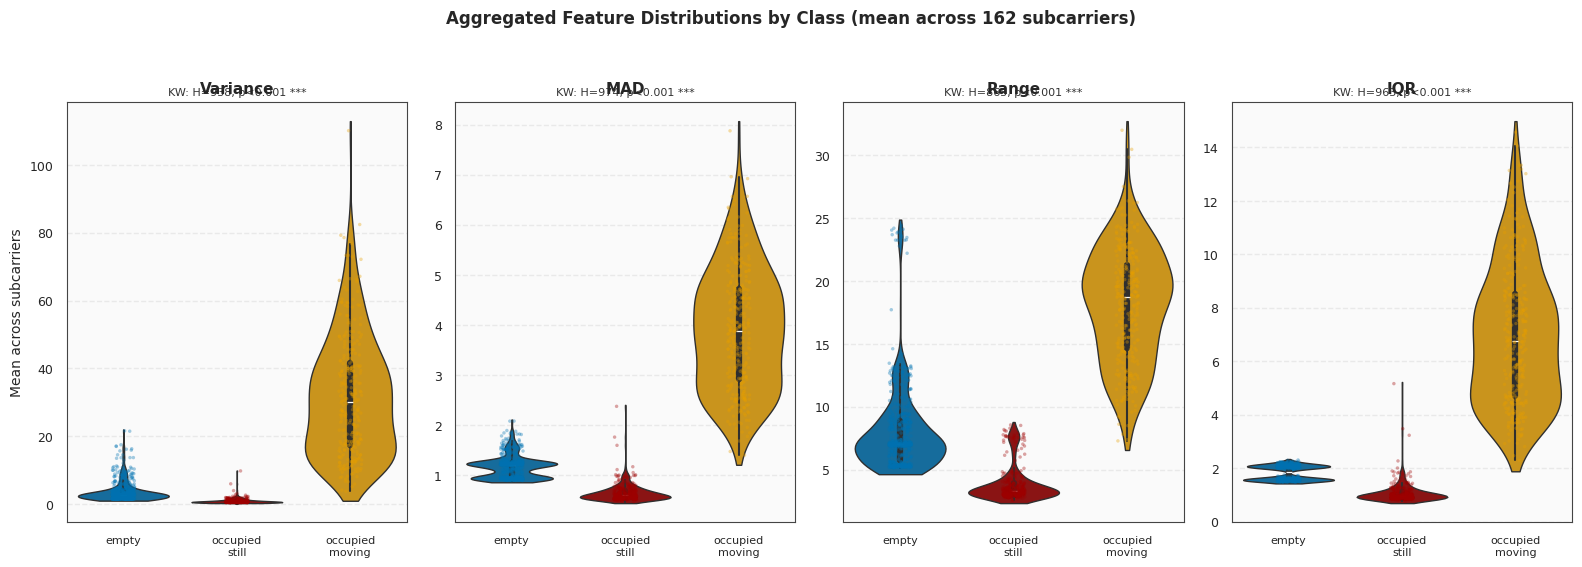

Figure saved: sep_03_feature_distributions.png


In [7]:
# Figure 3 - Aggregated feature distributions (3-class, violin + strip)
fig, axes = plt.subplots(1, 4, figsize=(16, 5.5), sharey=False)

df_plot = df[['label3', 'label_bin'] + [f'agg_{ft}' for ft in FT]].copy()
df_plot['label3_disp'] = df_plot['label3'].str.replace('_', '\n')

for i, ft in enumerate(FT):
    ax = axes[i]
    col = f'agg_{ft}'

    sns.violinplot(data=df_plot, x='label3', y=col,
                   order=ORDER_3CL, palette=PAL_3CL,
                   inner='box', cut=0.5, linewidth=1.0, ax=ax)
    sns.stripplot(data=df_plot, x='label3', y=col,
                  order=ORDER_3CL, palette=PAL_3CL,
                  size=2.5, alpha=0.35, jitter=True, ax=ax)

    # Kruskal-Wallis test
    groups = [df_plot.loc[df_plot['label3']==lbl, col].values for lbl in ORDER_3CL]
    h_stat, h_p = stats.kruskal(*groups)
    sig = '***' if h_p < 0.001 else ('**' if h_p < 0.01 else ('*' if h_p < 0.05 else 'ns'))
    ax.text(0.5, 1.01, f'KW: H={h_stat:.0f}, p{"<0.001" if h_p<0.001 else f"={h_p:.3f}"} {sig}',
            transform=ax.transAxes, ha='center', va='bottom', fontsize=8,
            color='#333333')

    ax.set_title(FT_LABELS[ft], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Mean across subcarriers' if i == 0 else '')
    ax.set_xticklabels([l.replace('_', '\n') for l in ORDER_3CL], fontsize=8)

fig.suptitle('Aggregated Feature Distributions by Class (mean across 162 subcarriers)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sep_03_feature_distributions.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: sep_03_feature_distributions.png")


In [8]:
# Statistical test summary table
rows = []
for ft in FT:
    col = f'agg_{ft}'
    x_empty = df.loc[df['label_bin']=='empty',   col].values
    x_occ   = df.loc[df['label_bin']=='occupied', col].values
    u_stat, u_p = stats.mannwhitneyu(x_empty, x_occ, alternative='two-sided')
    d = (abs(x_occ.mean() - x_empty.mean())
         / np.sqrt(((len(x_empty)-1)*x_empty.var() + (len(x_occ)-1)*x_occ.var())
                   / (len(x_empty)+len(x_occ)-2)))

    x_still  = df.loc[df['label3']=='occupied_still',  col].values
    x_moving = df.loc[df['label3']=='occupied_moving', col].values
    h3, p3   = stats.kruskal(x_empty, x_still, x_moving)

    # Cohen's d for still vs moving
    d_sm = (abs(x_moving.mean()-x_still.mean())
            / np.sqrt(((len(x_still)-1)*x_still.var()+(len(x_moving)-1)*x_moving.var())
                      / (len(x_still)+len(x_moving)-2)))

    rows.append({
        'Feature':              FT_LABELS[ft],
        'empty_mean':           f"{x_empty.mean():.3f}",
        'occ_mean':             f"{x_occ.mean():.3f}",
        "Mann-Whitney U":       f"{u_stat:.0f}",
        "Binary p-value":       f"{u_p:.2e}",
        "Binary Cohen's d":     f"{d:.3f}",
        "KW-H (3-class)":       f"{h3:.1f}",
        "3-class p-value":      f"{p3:.2e}",
        "Cohen's d (still/mov)":f"{d_sm:.3f}",
    })

tbl = pd.DataFrame(rows).set_index('Feature')
print("=== Statistical Test Summary ===")
print(tbl.to_string())


=== Statistical Test Summary ===
         empty_mean occ_mean Mann-Whitney U Binary p-value Binary Cohen's d KW-H (3-class) 3-class p-value Cohen's d (still/mov)
Feature                                                                                                                         
Variance      3.649   16.366         173772       3.00e-01            0.898          937.9       2.19e-204                 2.483
MAD           1.165    2.283         175325       4.36e-01            0.851          974.3       2.72e-212                 3.777
Range         8.039   10.977         175479       4.51e-01            0.486          865.4       1.20e-188                 4.232
IQR           1.832    4.027         173532       2.81e-01            0.890          963.2       6.92e-210                 3.215


---
## Section D - Per-subcarrier Discriminability

For each of the 162 valid subcarriers and each of the 4 feature types, a
**one-way ANOVA F-statistic** is computed as a measure of how strongly that
individual feature separates the classes.

$$F = \frac{\text{between-class variance}}{\text{within-class variance}}$$

Higher F → stronger class separation for that subcarrier-feature pair.
The heatmap allows identification of which subcarriers and which feature types
contribute most to class separability.


In [9]:
# ANOVA F-statistic per subcarrier (vectorized)
def f_stat_vec(groups_arrays):
    """Vectorized one-way ANOVA F-statistic across all feature columns.
    groups_arrays: list of (n_i, n_features) arrays, one per class.
    Returns: (n_features,) array of F-statistics.
    """
    n_g = len(groups_arrays)
    ns  = np.array([g.shape[0] for g in groups_arrays])
    n_total = ns.sum()

    means = np.stack([g.mean(0) for g in groups_arrays])   # (n_g, n_feat)
    grand  = (means * ns[:, None]).sum(0) / n_total

    ss_bet = ((means - grand)**2 * ns[:, None]).sum(0)
    ss_wit = sum(((g - g.mean(0))**2).sum(0) for g in groups_arrays)

    df_b = n_g - 1
    df_w = n_total - n_g
    F = (ss_bet / df_b) / (ss_wit / df_w + 1e-12)
    return F


# Binary groups
grp_bin = [df.loc[df['label']==lab, all_feat].values for lab in [0, 1]]
# 3-class groups
grp_3cl = [df.loc[df['label3']==lab, all_feat].values for lab in ORDER_3CL]

F_bin = f_stat_vec(grp_bin)  # (648,)
F_3cl = f_stat_vec(grp_3cl)  # (648,)

# Reshape into (4 feature_types × 162 subcarriers)
n_sc = len(feat_cols['var'])   # 162
F_bin_mat = np.stack([F_bin[i*n_sc:(i+1)*n_sc] for i, ft in enumerate(FT)])  # (4, 162)
F_3cl_mat = np.stack([F_3cl[i*n_sc:(i+1)*n_sc] for i, ft in enumerate(FT)])  # (4, 162)

print(f"F-stat range (binary)  - min: {F_bin.min():.1f}  median: {np.median(F_bin):.1f}  max: {F_bin.max():.1f}")
print(f"F-stat range (3-class) - min: {F_3cl.min():.1f}  median: {np.median(F_3cl):.1f}  max: {F_3cl.max():.1f}")

# Top 5 binary features
top_idx = np.argsort(F_bin)[::-1][:5]
print("\nTop 5 most discriminative features (binary):")
for rank, idx in enumerate(top_idx, 1):
    ft_i  = idx // n_sc
    sc_i  = idx %  n_sc
    print(f"  {rank}. sc{sc_i:03d}_{FT[ft_i]}  F={F_bin[idx]:.1f}")


F-stat range (binary)  - min: 0.0  median: 169.3  max: 377.1
F-stat range (3-class) - min: 137.8  median: 1259.5  max: 2253.5

Top 5 most discriminative features (binary):
  1. sc150_mad  F=377.1
  2. sc150_iqr  F=375.4
  3. sc150_var  F=289.4
  4. sc151_mad  F=286.2
  5. sc075_var  F=280.8


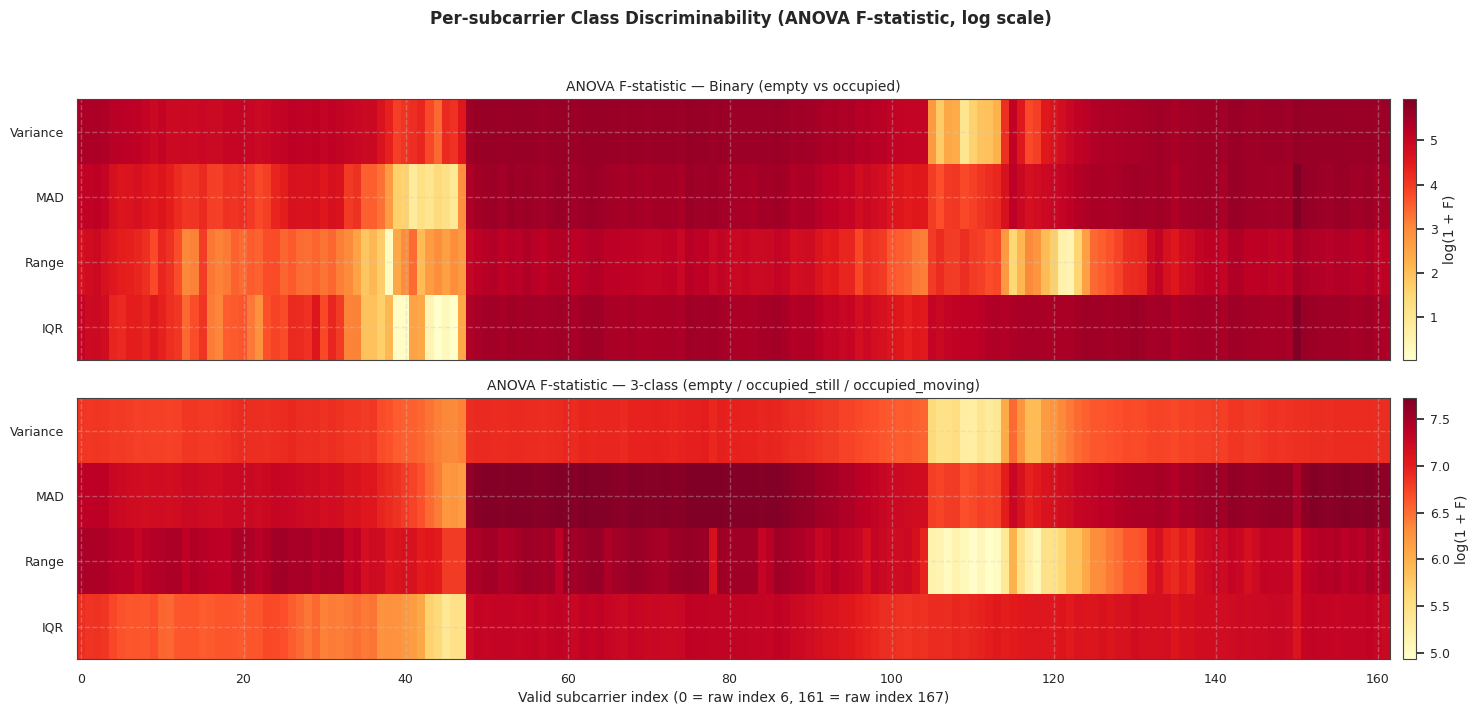

Figure saved: sep_04_discriminability_heatmap.png


In [10]:
# Figure 4a - ANOVA F-statistic heatmap (4 feature types × 162 subcarriers)
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

for ax, F_mat, title in zip(
        axes,
        [F_bin_mat, F_3cl_mat],
        ['Binary (empty vs occupied)', '3-class (empty / occupied_still / occupied_moving)']):

    vmax = np.percentile(F_mat, 98)
    im   = ax.imshow(np.log1p(F_mat), aspect='auto', cmap='YlOrRd',
                      interpolation='nearest')
    plt.colorbar(im, ax=ax, pad=0.01, fraction=0.02,
                 label='log(1 + F)')

    ax.set_yticks(range(4))
    ax.set_yticklabels([FT_LABELS[ft] for ft in FT])
    ax.set_title(f'ANOVA F-statistic - {title}', fontsize=10)

axes[1].set_xlabel('Valid subcarrier index (0 = raw index 6, 161 = raw index 167)')

fig.suptitle('Per-subcarrier Class Discriminability (ANOVA F-statistic, log scale)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sep_04_discriminability_heatmap.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: sep_04_discriminability_heatmap.png")


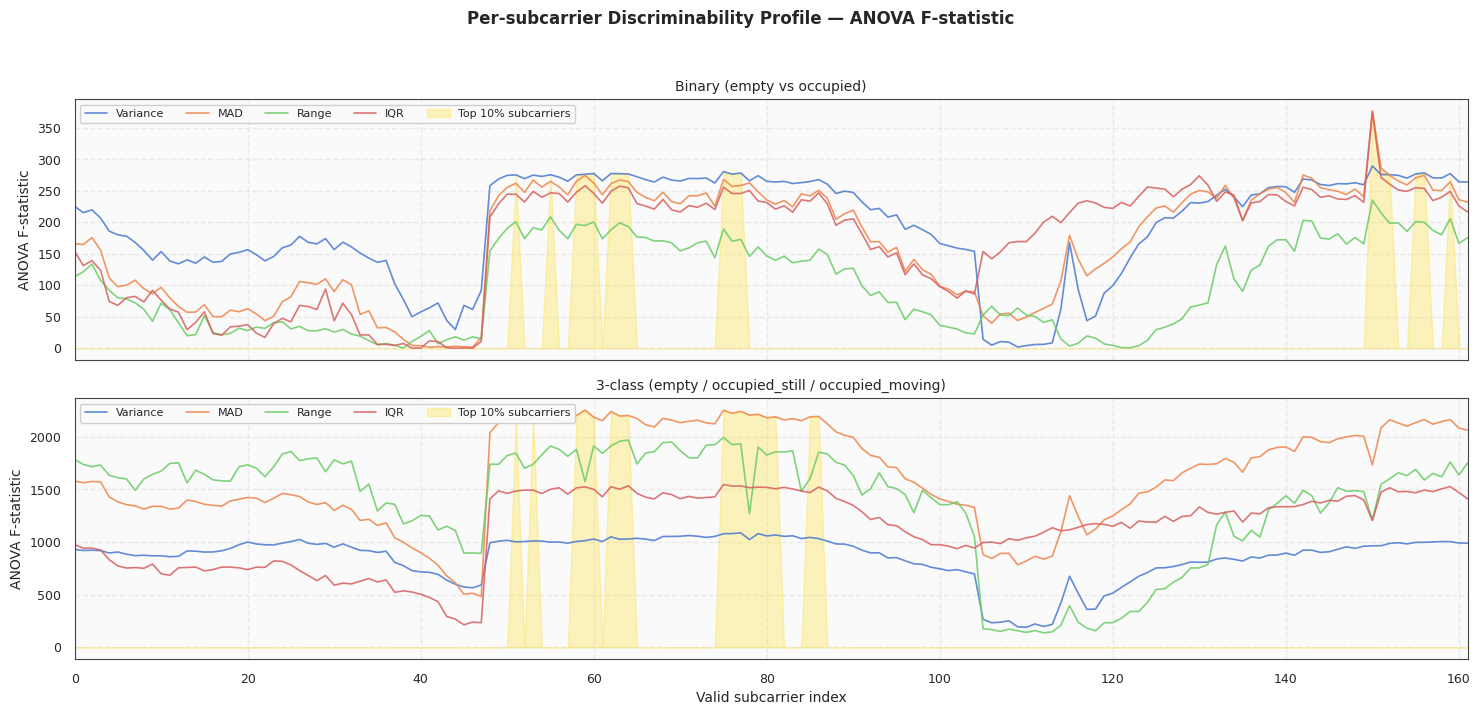

Figure saved: sep_04b_discriminability_profile.png


In [11]:
# Figure 4b - F-statistic profile per subcarrier (line plots, binary vs 3-class)
fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True, sharey=False)

sc_idx = sc_map['raw_subcarrier_index'].values  # raw indices for x-axis label
x      = np.arange(n_sc)

colors_ft = {'var': '#4878D0', 'mad': '#EE854A', 'range': '#6ACC65', 'iqr': '#D65F5F'}

for ax, F_mat, title in zip(
        axes,
        [F_bin_mat, F_3cl_mat],
        ['Binary (empty vs occupied)', '3-class (empty / occupied_still / occupied_moving)']):

    for i, ft in enumerate(FT):
        ax.plot(x, F_mat[i], lw=1.2, alpha=0.85,
                color=colors_ft[ft], label=FT_LABELS[ft])

    # Shade the top-10% most discriminative region
    top_thresh = np.percentile(F_mat.max(0), 90)
    top_mask   = F_mat.max(0) >= top_thresh
    ax.fill_between(x, 0, F_mat.max(0) * top_mask,
                    color='gold', alpha=0.25, label='Top 10% subcarriers')

    ax.set_ylabel('ANOVA F-statistic')
    ax.set_title(title, fontsize=10)
    ax.legend(loc='upper left', fontsize=8, ncol=5)
    ax.set_xlim(0, n_sc - 1)

axes[1].set_xlabel('Valid subcarrier index')

fig.suptitle('Per-subcarrier Discriminability Profile - ANOVA F-statistic',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sep_04b_discriminability_profile.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: sep_04b_discriminability_profile.png")


---
## Section E - Pairplot and Summary

Pairwise scatter matrix of the 4 aggregated features (mean across subcarriers),
coloured by 3-class label. Diagonal shows per-class KDE distributions.

This provides an at-a-glance view of how well individual feature pairs separate
the three conditions.


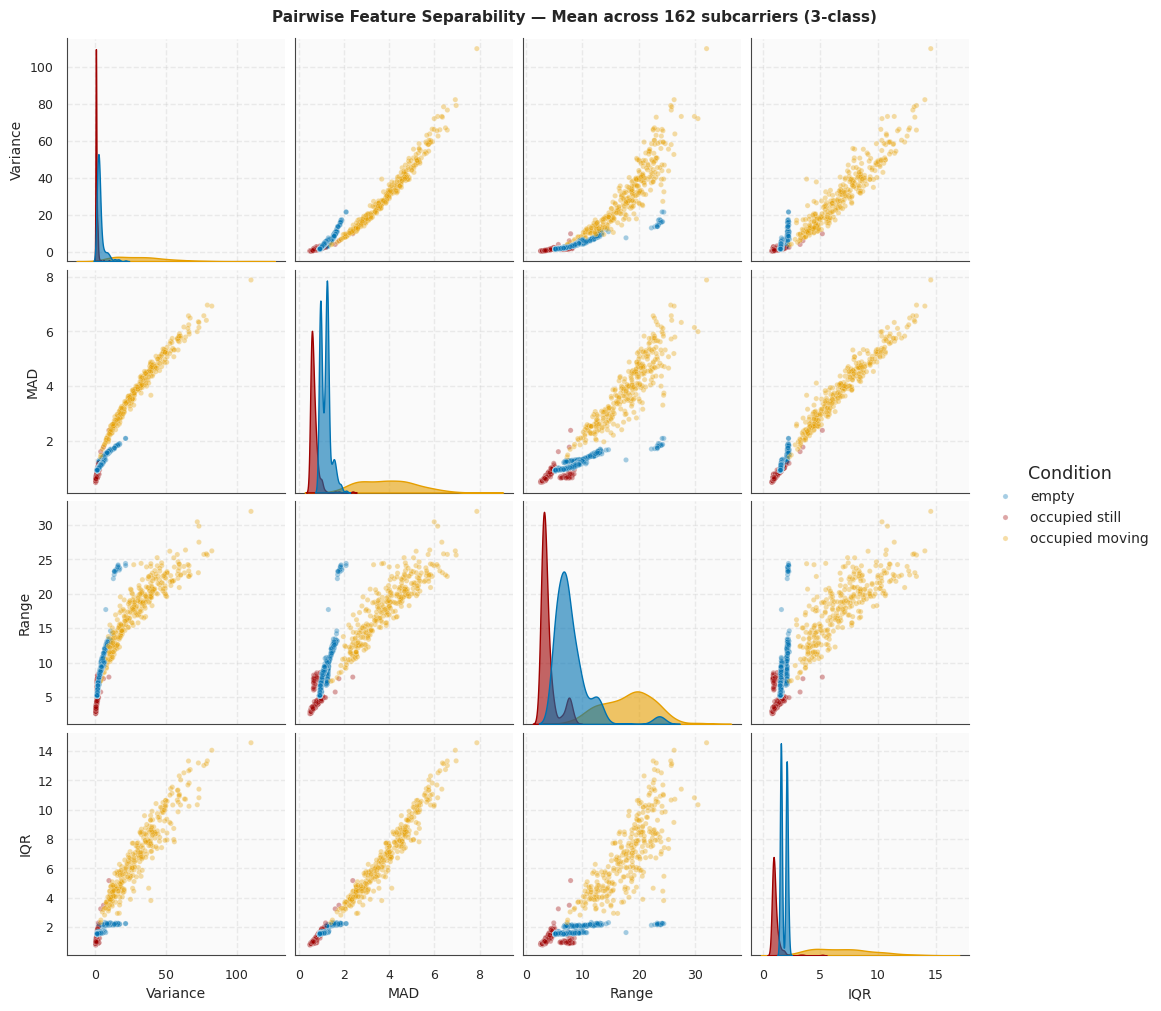

Figure saved: sep_05_pairplot.png


In [12]:
# Figure 5 - Pairplot of aggregated features (3-class)
df_pair = df[['label3'] + [f'agg_{ft}' for ft in FT]].copy()
df_pair.columns = ['Condition'] + [FT_LABELS[ft] for ft in FT]
df_pair['Condition'] = df_pair['Condition'].str.replace('_', ' ')

pal_pair = {
    'empty':           COLOR_EMPTY,
    'occupied still':  COLOR_STILL,
    'occupied moving': COLOR_MOVING,
}

g = sns.pairplot(
    df_pair,
    vars=[FT_LABELS[ft] for ft in FT],
    hue='Condition',
    palette=pal_pair,
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 14, 'rasterized': True},
    diag_kws={'alpha': 0.6, 'fill': True},
    corner=False,
)
g.figure.suptitle(
    'Pairwise Feature Separability - Mean across 162 subcarriers (3-class)',
    fontsize=11, fontweight='bold', y=1.01,
)
g.figure.savefig(OUTPUT_DIR / 'sep_05_pairplot.png', dpi=200,
                 bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: sep_05_pairplot.png")


In [13]:
# Top discriminative subcarriers per feature type (binary ANOVA)
print("=== Top 10 subcarriers per feature type (binary ANOVA F) ===\n")
for i, ft in enumerate(FT):
    f_row = F_bin_mat[i]
    top10 = np.argsort(f_row)[::-1][:10]
    raw_top10 = sc_map.iloc[top10]['raw_subcarrier_index'].values
    print(f"{FT_LABELS[ft]}:")
    print(f"  Valid indices (0-based): {top10.tolist()}")
    print(f"  Raw indices            : {raw_top10.tolist()}")
    print(f"  F-stats                : {np.round(f_row[top10], 1).tolist()}")
    print()


=== Top 10 subcarriers per feature type (binary ANOVA F) ===

Variance:
  Valid indices (0-based): [150, 75, 156, 77, 60, 62, 159, 63, 64, 155]
  Raw indices            : [179, 93, 185, 95, 78, 80, 188, 81, 82, 184]
  F-stats                : [289.4, 280.8, 278.7, 278.5, 277.6, 277.6, 277.4, 277.4, 276.9, 276.9]

MAD:
  Valid indices (0-based): [150, 151, 142, 156, 59, 152, 155, 143, 75, 63]
  Raw indices            : [179, 180, 171, 185, 77, 181, 184, 172, 93, 81]
  F-stats                : [377.1, 286.2, 275.2, 274.9, 274.6, 274.5, 270.6, 269.9, 268.2, 267.5]

Range:
  Valid indices (0-based): [150, 151, 55, 159, 142, 143, 155, 51, 60, 156]
  Raw indices            : [179, 180, 73, 188, 171, 172, 184, 69, 78, 185]
  F-stats                : [235.4, 215.2, 208.7, 206.0, 203.2, 202.1, 201.1, 201.0, 200.6, 200.0]

IQR:
  Valid indices (0-based): [150, 130, 151, 152, 129, 131, 59, 63, 124, 75]
  Raw indices            : [179, 159, 180, 181, 158, 160, 77, 81, 153, 93]
  F-stats           

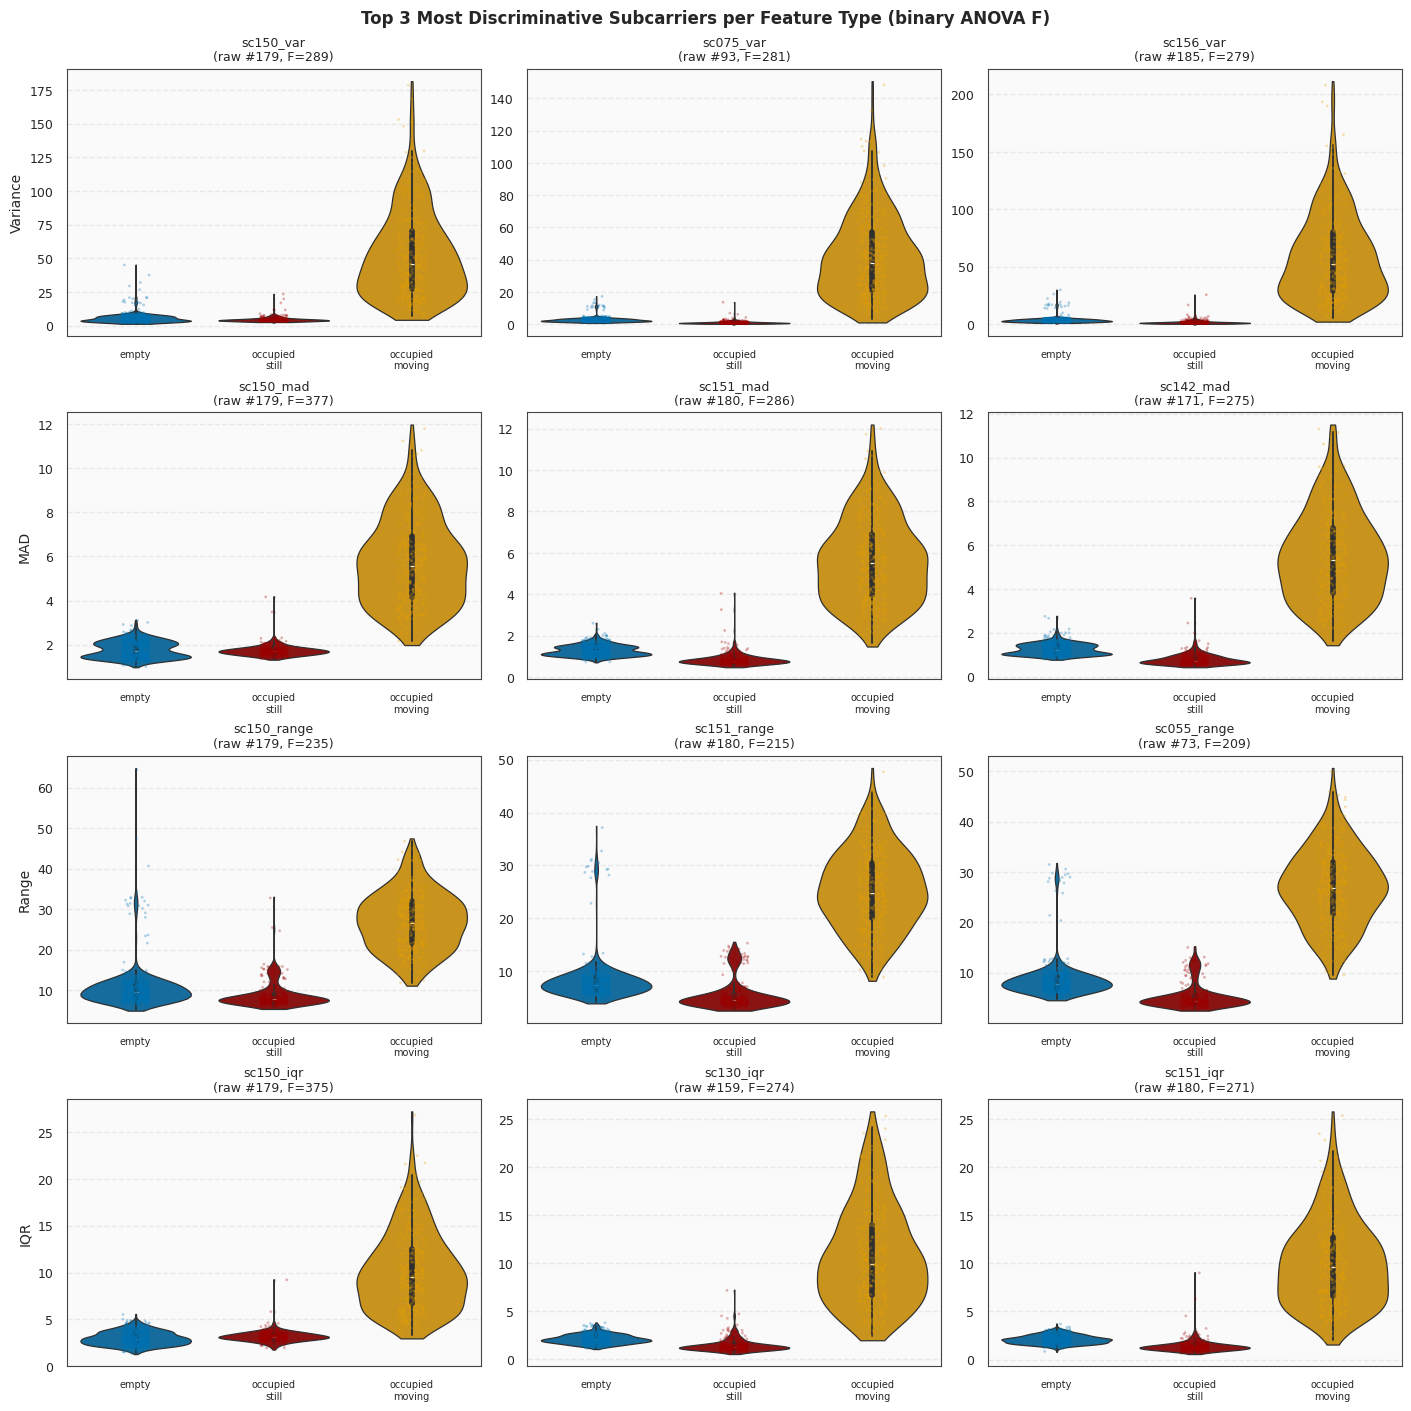

Figure saved: sep_06_top_features.png


In [14]:
# Figure 6 - Top 3 most discriminative features per type: violin (3-class)
fig, axes = plt.subplots(4, 3, figsize=(14, 14), constrained_layout=True)

for row, ft in enumerate(FT):
    f_row  = F_bin_mat[row]
    top3   = np.argsort(f_row)[::-1][:3]
    cols_t = [feat_cols[ft][j] for j in top3]

    for col_i, (sc_i, col) in enumerate(zip(top3, cols_t)):
        ax = axes[row, col_i]
        raw_idx = sc_map.iloc[sc_i]['raw_subcarrier_index']

        df_tmp = df[['label3', col]].copy()
        df_tmp.columns = ['Condition', 'value']

        sns.violinplot(data=df_tmp, x='Condition', y='value',
                       order=ORDER_3CL, palette=PAL_3CL,
                       inner='box', cut=0.3, linewidth=0.9, ax=ax)
        sns.stripplot(data=df_tmp, x='Condition', y='value',
                      order=ORDER_3CL, palette=PAL_3CL,
                      size=2.0, alpha=0.30, jitter=True, ax=ax)

        f_val = f_row[sc_i]
        ax.set_title(f'sc{sc_i:03d}_{ft}\n(raw #{raw_idx}, F={f_val:.0f})',
                     fontsize=9)
        ax.set_xlabel('')
        ax.set_ylabel(FT_LABELS[ft] if col_i == 0 else '')
        ax.set_xticklabels([l.replace('_', '\n') for l in ORDER_3CL], fontsize=7)

fig.suptitle(
    'Top 3 Most Discriminative Subcarriers per Feature Type (binary ANOVA F)',
    fontsize=12, fontweight='bold',
)
plt.savefig(OUTPUT_DIR / 'sep_06_top_features.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: sep_06_top_features.png")


---
## Summary

| Figure | File | Description |
|--------|------|-------------|
| 1 | `sep_01_pca.png` | PCA scree + binary scatter + 3-class scatter |
| 2 | `sep_02_lda.png` | LDA 1D projection (binary) + 2D (3-class) |
| 3 | `sep_03_feature_distributions.png` | Violin plots of 4 aggregated features |
| 4a | `sep_04_discriminability_heatmap.png` | ANOVA F-statistic heatmap (log scale) |
| 4b | `sep_04b_discriminability_profile.png` | F-statistic profile per subcarrier |
| 5 | `sep_05_pairplot.png` | Pairplot of 4 aggregated features |
| 6 | `sep_06_top_features.png` | Top-3 subcarriers per feature type |

### Key findings to look for

1. **PCA** (Fig. 1): Do classes cluster in the PC1–PC2 plane?
   The 2σ ellipses should show minimal overlap for good separability.

2. **LDA** (Fig. 2): Cohen's d > 1 indicates large binary effect size.
   In the 3-class LDA, separation between all three clusters confirms
   that *occupied_still* and *occupied_moving* are distinguishable even though
   they share the same binary label.

3. **Feature distributions** (Fig. 3): MAD and IQR typically capture temporal
   variability best. Variance and Range may be dominated by outlier windows.

4. **Discriminability** (Fig. 4): Subcarriers in mid-range frequency positions
   (far from DC) often show higher F-statistics due to richer multipath information.

5. **Pairplot** (Fig. 5): Feature pairs that show clear cluster separation can be
   used as hand-crafted features for lightweight ML models.


In [15]:
# Final confirmation: all output files
print("Output figures in:", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.glob('sep_*.png')):
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")


Output figures in: /home/xavier/code/wifi-csi-presence-detection/pilot/outputs/figures
  sep_01_pca.png  (411 KB)
  sep_02_lda.png  (440 KB)
  sep_03_feature_distributions.png  (368 KB)
  sep_04_discriminability_heatmap.png  (201 KB)
  sep_04b_discriminability_profile.png  (622 KB)
  sep_05_pairplot.png  (695 KB)
  sep_06_top_features.png  (859 KB)
